# Jun & Jul — Diurnal Cycle in C[h,h] (Diagonal)

**목적**: 6월과 7월만 추려서 outlier 제거 후 diurnal cycle (C[h,h] diagonal)의
연도별 일관성을 집중 분석

**주목 이유**: 다른 달은 연도별 baseline 자체가 크게 흔들리지만,
6월·7월은 outlier 제거 후에도 h7 spike + h0–h6 완만한 패턴이 연도별로 일관됨

**데이터**: GEMS TCO 2022–2025, lat [−3, 2], lon [121, 131]

In [9]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

YEARS       = ['2022', '2023', '2024', '2025']
MONTHS      = [6, 7]
MONTH_NAMES = {6: 'Jun', 7: 'Jul'}
N_SLOTS     = 8
SLOT_LABELS = [f'h{h}' for h in range(N_SLOTS)]

CACHE_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/df_spatial_stats_cache.pkl")
assert CACHE_PATH.exists(), f"Cache not found: {CACHE_PATH}"
df_all = pd.read_pickle(CACHE_PATH)
print(f"Loaded: {len(df_all)} rows | columns: {list(df_all.columns)}")

Loaded: 5808 rows | columns: ['year', 'month', 'day_idx', 'slot', 'hours_elapsed', 'spatial_mean', 'spatial_std', 'sem_lat_lag1', 'sem_lon_lag1', 'n_obs', 'spatial_mean_c']


In [10]:
def build_Y(sub_df):
    """(year, day_idx) 순서로 정렬 후 n_days × 8 행렬 반환."""
    day_order = (
        sub_df.groupby(['year', 'day_idx'])['hours_elapsed']
              .min().reset_index()
              .sort_values(['year', 'day_idx'])
    )
    mat_rows = []
    for _, row in day_order.iterrows():
        yr, d_idx = int(row['year']), int(row['day_idx'])
        s = sub_df[(sub_df['year'] == yr) & (sub_df['day_idx'] == d_idx)]
        vec = np.full(N_SLOTS, np.nan)
        for _, r in s.iterrows():
            vec[int(r['slot'])] = r['spatial_mean_c']
        mat_rows.append(vec)
    return np.array(mat_rows)


def sample_cov_matrix(Y):
    n_s = Y.shape[1]
    C = np.full((n_s, n_s), np.nan)
    for h1 in range(n_s):
        for h2 in range(n_s):
            mask = np.isfinite(Y[:, h1]) & np.isfinite(Y[:, h2])
            if mask.sum() > 1:
                C[h1, h2] = np.mean(Y[mask, h1] * Y[mask, h2])
    return C


def find_outlier_days(df_mo, iqr_mult=1.5):
    """모든 slot에 IQR 검정 → 어느 slot이든 벗어나면 해당 day 전체 제거."""
    outlier_days = set()
    details = []
    for slot in range(N_SLOTS):
        sub_slot = df_mo[df_mo['slot'] == slot]['spatial_mean_c'].dropna()
        q1, q3 = sub_slot.quantile(0.25), sub_slot.quantile(0.75)
        iqr = q3 - q1
        upper, lower = q3 + iqr_mult * iqr, q1 - iqr_mult * iqr
        mask = (df_mo['slot'] == slot) & (
            (df_mo['spatial_mean_c'] > upper) | (df_mo['spatial_mean_c'] < lower)
        )
        for _, r in df_mo[mask].iterrows():
            key = (int(r['year']), int(r['day_idx']))
            outlier_days.add(key)
            details.append({
                'slot': f'h{slot}', 'year': int(r['year']),
                'day_idx': int(r['day_idx']),
                'val': round(r['spatial_mean_c'], 2),
                'upper': round(upper, 2), 'lower': round(lower, 2)
            })
    df_det = pd.DataFrame(details).sort_values(['year', 'day_idx', 'slot']) if details else pd.DataFrame()
    return outlier_days, df_det

print("Helpers ready.")

Helpers ready.


## Step 1 — Outlier 제거 + 연도별 C[h,h] 테이블

In [11]:
all_results = {}

for mo in MONTHS:
    df_mo = df_all[df_all['month'] == mo].copy()
    mname = MONTH_NAMES[mo]

    print("=" * 60)
    print(f"  {mname} (month={mo})")
    print("=" * 60)

    outlier_days, df_det = find_outlier_days(df_mo)

    if len(outlier_days) == 0:
        print("  No outlier days.\n")
    else:
        print(f"  Outlier days ({len(outlier_days)} unique):")
        for yr_k, d_k in sorted(outlier_days):
            triggered = df_det[(df_det['year'] == yr_k) & (df_det['day_idx'] == d_k)]
            info = ", ".join(
                f"{r['slot']}={r['val']} (bounds [{r['lower']}, {r['upper']}])"
                for _, r in triggered.iterrows()
            )
            print(f"    year={yr_k}  day_idx={d_k}  →  {info}")
        print()

    if outlier_days:
        keep = ~df_mo.apply(
            lambda r: (int(r['year']), int(r['day_idx'])) in outlier_days, axis=1
        )
        df_clean = df_mo[keep].copy()
    else:
        df_clean = df_mo.copy()

    yearly_C, yearly_n = {}, {}
    for yr in YEARS:
        sub = df_clean[df_clean['year'] == int(yr)]
        if len(sub) == 0:
            continue
        Y = build_Y(sub)
        yearly_n[yr] = Y.shape[0]
        yearly_C[yr] = sample_cov_matrix(Y)

    print(f"  C[h,h] after outlier removal:\n")
    for yr in YEARS:
        if yr not in yearly_C:
            continue
        diag = np.diag(yearly_C[yr])
        parts = "  ".join(f"h{h}={diag[h]:.2f}" for h in range(N_SLOTS))
        print(f"  {yr}  ({yearly_n[yr]} days)")
        print(f"    {parts}\n")

    all_results[mo] = {
        'outlier_days': outlier_days,
        'yearly_C': yearly_C,
        'yearly_n': yearly_n,
        'df_clean': df_clean,
    }

  Jun (month=6)
  Outlier days (1 unique):
    year=2023  day_idx=11  →  h4=-7.41 (bounds [-7.11, 6.17]), h6=-6.15 (bounds [-5.92, 6.8])

  C[h,h] after outlier removal:

  2022  (30 days)
    h0=7.35  h1=7.67  h2=7.99  h3=8.03  h4=7.74  h5=7.76  h6=7.67  h7=10.82

  2023  (29 days)
    h0=6.45  h1=7.01  h2=7.66  h3=8.07  h4=8.04  h5=8.41  h6=7.87  h7=12.39

  2024  (30 days)
    h0=4.70  h1=4.64  h2=5.58  h3=6.18  h4=6.19  h5=6.79  h6=6.02  h7=11.42

  2025  (30 days)
    h0=6.54  h1=6.33  h2=6.81  h3=6.61  h4=5.78  h5=5.32  h6=4.36  h7=10.12

  Jul (month=7)
  Outlier days (4 unique):
    year=2022  day_idx=0  →  h0=-8.56 (bounds [-6.8, 7.13]), h1=-8.35 (bounds [-7.34, 6.98]), h2=-8.17 (bounds [-7.69, 6.34]), h3=-7.78 (bounds [-7.42, 6.13])
    year=2023  day_idx=30  →  h0=-6.88 (bounds [-6.8, 7.13]), h3=-7.66 (bounds [-7.42, 6.13]), h4=-7.52 (bounds [-7.27, 6.33])
    year=2024  day_idx=23  →  h0=7.31 (bounds [-6.8, 7.13])
    year=2024  day_idx=30  →  h2=-7.9 (bounds [-7.69, 6.34])

## Step 2 — Raw C[h,h] Diurnal Cycle Plot (Jun vs Jul)

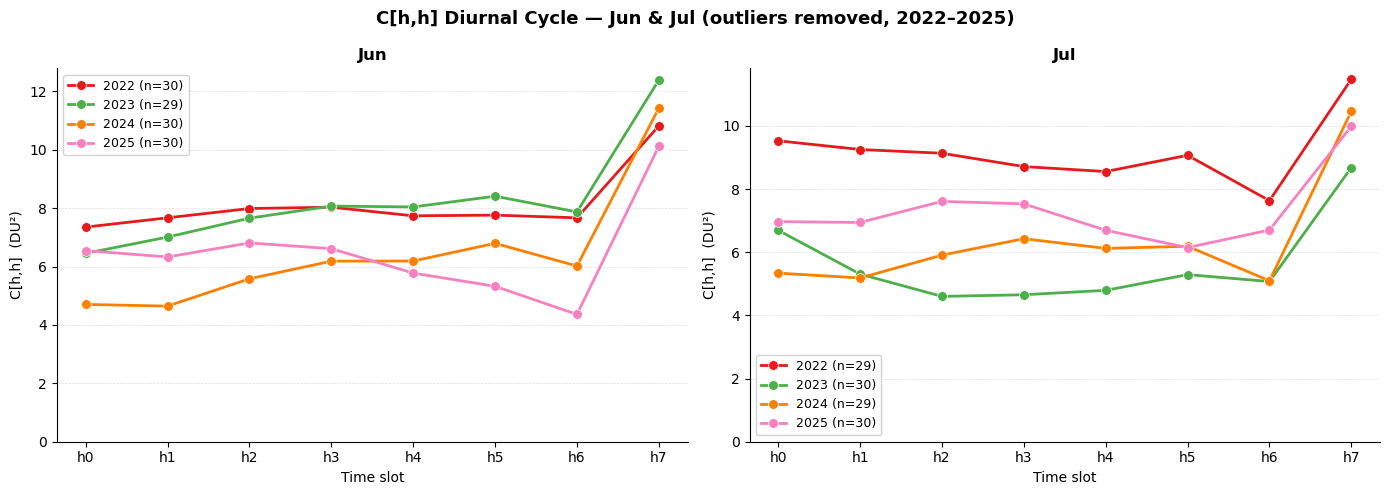

Saved → jun_jul_diag_raw.png


In [12]:
OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/jun_jul_diag_cycle/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

year_colors = plt.cm.Set1(np.linspace(0, 0.8, len(YEARS)))
YEAR_PAL = dict(zip(YEARS, year_colors))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('C[h,h] Diurnal Cycle — Jun & Jul (outliers removed, 2022–2025)',
             fontsize=13, fontweight='bold')

for ax, mo in zip(axes, MONTHS):
    res = all_results[mo]
    for yr in YEARS:
        if yr not in res['yearly_C']:
            continue
        diag = np.diag(res['yearly_C'][yr])
        n = res['yearly_n'][yr]
        ax.plot(range(N_SLOTS), diag, 'o-',
                color=YEAR_PAL[yr], lw=2, ms=7,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'{yr} (n={n})')

    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(N_SLOTS))
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=10)
    ax.set_ylabel('C[h,h]  (DU²)', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig(OUT_DIR / 'jun_jul_diag_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → jun_jul_diag_raw.png")

## Step 3 — Normalized Shape: C[h,h] / mean(C[h0:h6])

h7이 특이값인지, 아니면 전체 scale이 달라서인지 구분하기 위해
h0–h6 평균으로 정규화해서 **shape** 만 비교

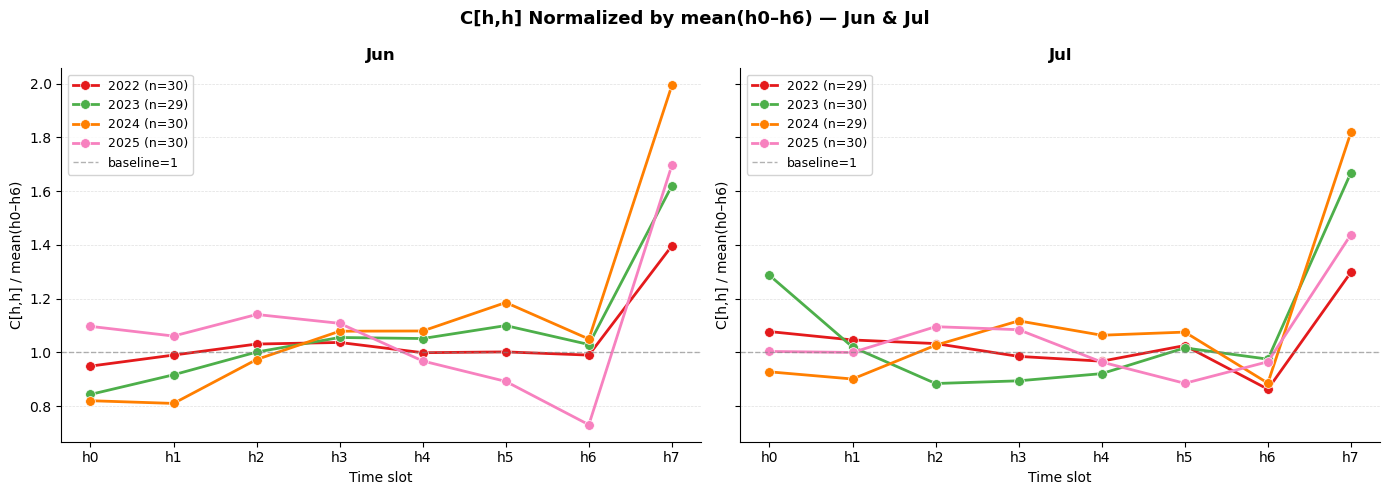

Saved → jun_jul_diag_normalized.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('C[h,h] Normalized by mean(h0–h6) — Jun & Jul',
             fontsize=13, fontweight='bold')

for ax, mo in zip(axes, MONTHS):
    res = all_results[mo]
    for yr in YEARS:
        if yr not in res['yearly_C']:
            continue
        diag = np.diag(res['yearly_C'][yr])
        baseline = np.mean(diag[:7])          # h0–h6 평균
        norm_diag = diag / baseline
        n = res['yearly_n'][yr]
        ax.plot(range(N_SLOTS), norm_diag, 'o-',
                color=YEAR_PAL[yr], lw=2, ms=7,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'{yr} (n={n})')

    ax.axhline(1.0, color='gray', ls='--', lw=1.0, alpha=0.6, label='baseline=1')
    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(N_SLOTS))
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=10)
    ax.set_ylabel('C[h,h] / mean(h0–h6)', fontsize=10)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig(OUT_DIR / 'jun_jul_diag_normalized.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → jun_jul_diag_normalized.png")

## Step 4 — h7 Spike Ratio: C[7,7] / mean(C[h,h] for h=0..6)

연도별 h7 돌출 강도를 수치로 정리

In [14]:
print(f"{'Month':>5}  {'Year':>5}  {'C[7,7]':>8}  {'mean(h0-h6)':>12}  {'ratio h7/mean':>14}")
print("-" * 55)
for mo in MONTHS:
    res = all_results[mo]
    for yr in YEARS:
        if yr not in res['yearly_C']:
            continue
        diag = np.diag(res['yearly_C'][yr])
        baseline = np.mean(diag[:7])
        ratio = diag[7] / baseline
        print(f"  {MONTH_NAMES[mo]:>3}   {yr:>5}   {diag[7]:>7.2f}   {baseline:>11.2f}   {ratio:>13.3f}")
    print()

Month   Year    C[7,7]   mean(h0-h6)   ratio h7/mean
-------------------------------------------------------
  Jun    2022     10.82          7.74           1.397
  Jun    2023     12.39          7.64           1.620
  Jun    2024     11.42          5.73           1.994
  Jun    2025     10.12          5.96           1.697

  Jul    2022     11.48          8.84           1.298
  Jul    2023      8.68          5.20           1.669
  Jul    2024     10.46          5.75           1.819
  Jul    2025      9.99          6.94           1.439



## Step 5 — h0–h6 Raw C[h,h] (h7 제외)

h7 spike 없애고 h0–h6 구간만 raw값으로 봐서 Jun vs Jul 내부 shape 차이 확인

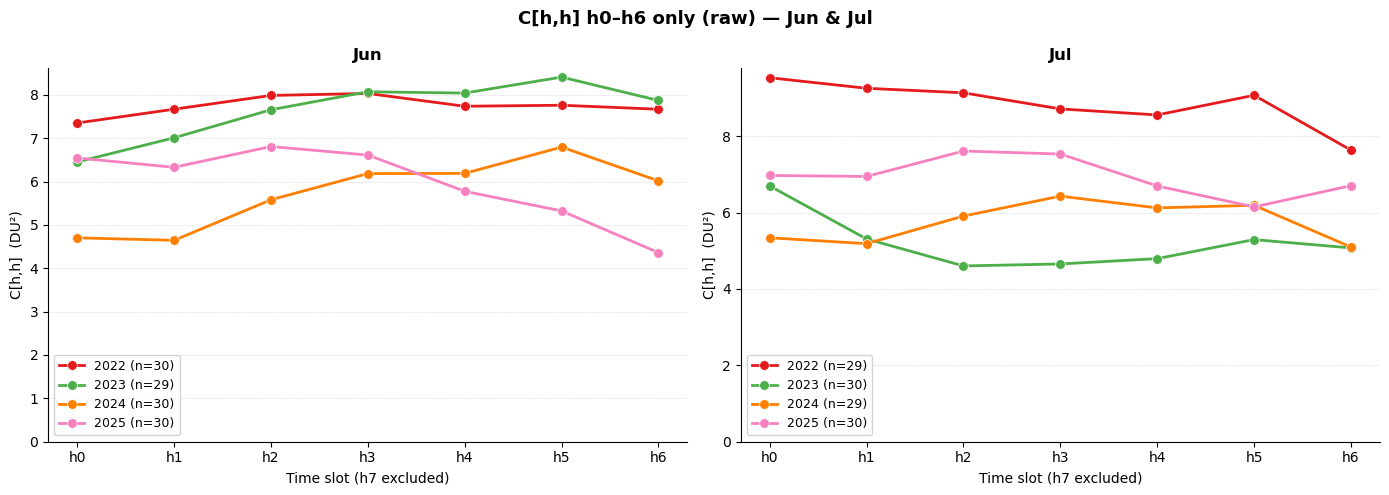

Saved → jun_jul_diag_h0h6_raw.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('C[h,h] h0–h6 only (raw) — Jun & Jul',
             fontsize=13, fontweight='bold')

for ax, mo in zip(axes, MONTHS):
    res = all_results[mo]
    for yr in YEARS:
        if yr not in res['yearly_C']:
            continue
        diag = np.diag(res['yearly_C'][yr])[:7]   # h0–h6 only
        n = res['yearly_n'][yr]
        ax.plot(range(7), diag, 'o-',
                color=YEAR_PAL[yr], lw=2, ms=7,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'{yr} (n={n})')

    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(7))
    ax.set_xticklabels(SLOT_LABELS[:7], fontsize=10)
    ax.set_xlabel('Time slot (h7 excluded)', fontsize=10)
    ax.set_ylabel('C[h,h]  (DU²)', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig(OUT_DIR / 'jun_jul_diag_h0h6_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → jun_jul_diag_h0h6_raw.png")

## Step 6 — Overall Mean Diurnal Cycle: E[X_h] per Year

variance cycle이 아니라 **raw mean** — 각 slot h에서 `spatial_mean_c`의 연도별 평균값

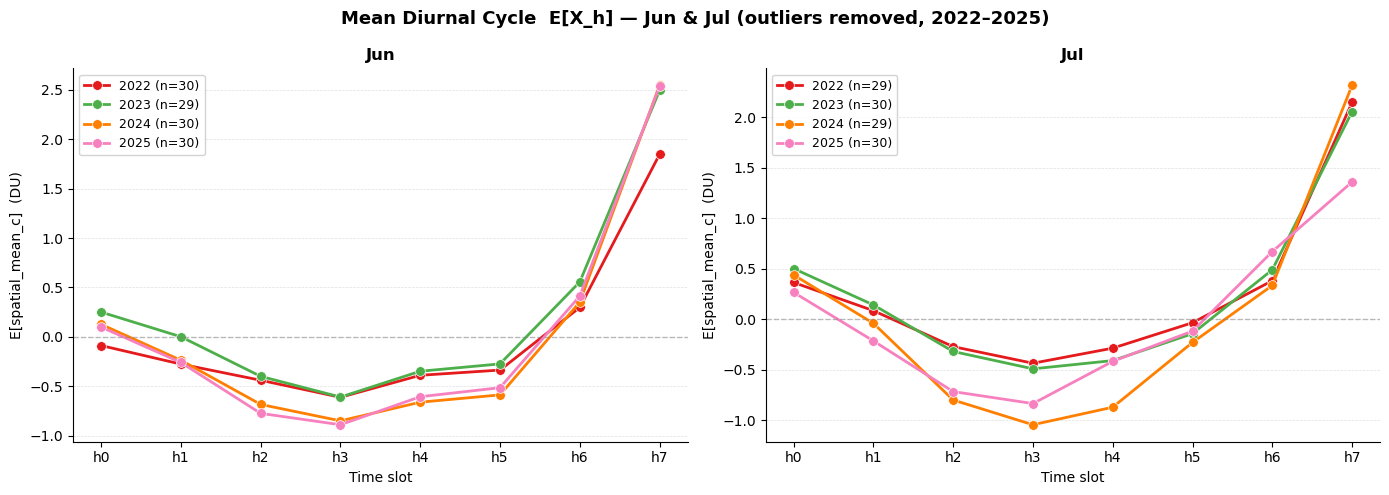

Saved → jun_jul_mean_diurnal.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Mean Diurnal Cycle  E[X_h] — Jun & Jul (outliers removed, 2022–2025)',
             fontsize=13, fontweight='bold')

for ax, mo in zip(axes, MONTHS):
    res = all_results[mo]
    df_clean = res['df_clean']

    for yr in YEARS:
        sub = df_clean[df_clean['year'] == int(yr)]
        if len(sub) == 0:
            continue
        # slot별 mean
        slot_mean = (
            sub.groupby('slot')['spatial_mean_c']
               .mean()
               .reindex(range(N_SLOTS))
        )
        n = res['yearly_n'].get(yr, '?')
        ax.plot(range(N_SLOTS), slot_mean.values, 'o-',
                color=YEAR_PAL[yr], lw=2, ms=7,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'{yr} (n={n})')

    ax.axhline(0, color='gray', ls='--', lw=1.0, alpha=0.5)
    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(N_SLOTS))
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=10)
    ax.set_ylabel('E[spatial_mean_c]  (DU)', fontsize=10)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig(OUT_DIR / 'jun_jul_mean_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → jun_jul_mean_diurnal.png")